Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**  
Course: **Computer Engineering - Artificial Intelligence / Machine Learning**

**ASSESSMENT 1 - 10 Slope Prediction Model**


---

#### **I. Import Libraries and Initialize Functions**

In [1]:
import tensorflow as tf 
import pandas as pd 
import numpy as np 
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

print(f'tensorflow: {tf.__version__}\n', 
      f'pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}')

I0000 00:00:1778685025.059571    4778 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow: 2.21.0
 pandas: 3.0.2
 numpy: 2.4.2
 sklearn: 1.8.0


In [2]:
def pltpred (train_data, 
             train_labels,
             test_data, 
             test_labels,
             predictions):
    
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c="b", label="Training data")
    plt.scatter(test_data, test_labels, c="g", label="Testing data")
    plt.scatter(test_data, predictions, c="r", label="Predictions")
    plt.legend();

#### **II. Prep Dataset**

Create the dataset.

In [3]:
# Create features
x = np.arange(-200, 200, 4)

# Create labels
y = x + 20


x, y 

(array([-200, -196, -192, -188, -184, -180, -176, -172, -168, -164, -160,
        -156, -152, -148, -144, -140, -136, -132, -128, -124, -120, -116,
        -112, -108, -104, -100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,
         -68,  -64,  -60,  -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,
         -24,  -20,  -16,  -12,   -8,   -4,    0,    4,    8,   12,   16,
          20,   24,   28,   32,   36,   40,   44,   48,   52,   56,   60,
          64,   68,   72,   76,   80,   84,   88,   92,   96,  100,  104,
         108,  112,  116,  120,  124,  128,  132,  136,  140,  144,  148,
         152,  156,  160,  164,  168,  172,  176,  180,  184,  188,  192,
         196]),
 array([-180, -176, -172, -168, -164, -160, -156, -152, -148, -144, -140,
        -136, -132, -128, -124, -120, -116, -112, -108, -104, -100,  -96,
         -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,  -56,  -52,
         -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,  -12,   -8,
          -4,    0,   

Split the dataset into training and testing sets.

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size= 0.2,
                                                    random_state=42,
                                                    shuffle=False
                                                    )

Normalize the data using `StandardScaler()` (for models that require it)

In [5]:
scaler = StandardScaler()

x_train_reshaped = x_train.reshape(-1, 1)
x_test_reshaped = x_test.reshape(-1, 1)

x_train_scaled = scaler.fit_transform(x_train_reshaped)
x_test_scaled = scaler.transform(x_test_reshaped)

x_train_scaled, x_test_scaled, x_train, x_test

(array([[-1.71053381],
        [-1.66722916],
        [-1.62392451],
        [-1.58061985],
        [-1.5373152 ],
        [-1.49401055],
        [-1.45070589],
        [-1.40740124],
        [-1.36409659],
        [-1.32079193],
        [-1.27748728],
        [-1.23418262],
        [-1.19087797],
        [-1.14757332],
        [-1.10426866],
        [-1.06096401],
        [-1.01765936],
        [-0.9743547 ],
        [-0.93105005],
        [-0.8877454 ],
        [-0.84444074],
        [-0.80113609],
        [-0.75783144],
        [-0.71452678],
        [-0.67122213],
        [-0.62791748],
        [-0.58461282],
        [-0.54130817],
        [-0.49800352],
        [-0.45469886],
        [-0.41139421],
        [-0.36808955],
        [-0.3247849 ],
        [-0.28148025],
        [-0.23817559],
        [-0.19487094],
        [-0.15156629],
        [-0.10826163],
        [-0.06495698],
        [-0.02165233],
        [ 0.02165233],
        [ 0.06495698],
        [ 0.10826163],
        [ 0

Visualize the data.

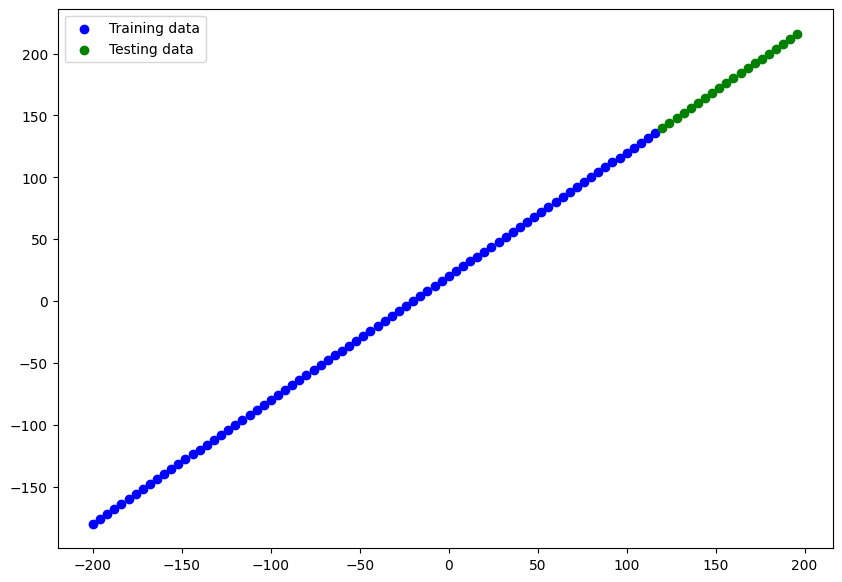

In [6]:
plt.figure(figsize=(10, 7))
# Plot training data in blue
plt.scatter(x_train, y_train, c='b', label='Training data')
# Plot test data in green
plt.scatter(x_test, y_test, c='g', label='Testing data')
# Show the legend
plt.legend();

#### **III. Create Models**

#### **Model 1 - Barebone Single Neuron Approach**

The simplest / barebones model.

##### Create and compile model

In [7]:
model1 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(1)
])

model1.compile(loss='mse',
              optimizer='adam',
              metrics=["mse"]
              )

I0000 00:00:1778685031.119897    4778 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


##### Show model summary

In [8]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [ ]:
history1 = model1.fit(tf.expand_dims(x_train, axis=-1), y_train, 
                      epochs=10)

Epoch 1/10


I0000 00:00:1778685033.269569    6694 service.cc:153] XLA service 0x784cd002efb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778685033.269623    6694 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.3.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1778685033.304335    6694 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778685033.372695    6694 cuda_dnn.cc:461] Loaded cuDNN version 92000


1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 995ms/step - loss: 28918.1523 - mse: 28918.1523

I0000 00:00:1778685033.681865    6694 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - loss: 27341.6719 - mse: 27341.6719
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 27240.3867 - mse: 27240.3867
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 27136.6152 - mse: 27136.6152
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 27046.2402 - mse: 27046.2402
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 26947.8281 - mse: 26947.8281
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 26847.3867 - mse: 26847.3867
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 26754.9258 - mse: 26754.9258
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 26654.3066 - mse: 26654.3066
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 26558.8086 - mse: 26558.8086
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 26459.7754 - mse: 26459.7754


Evaluate the model.

In [10]:
model1.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - loss: 82317.3281 - mse: 82317.3281


[82317.328125, 82317.328125]

##### Showcase results.

In [11]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (36.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6 (28.00 B)

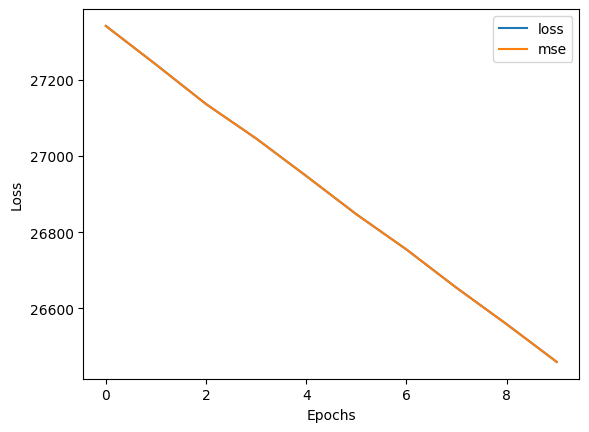

In [12]:
pd.DataFrame(history1.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


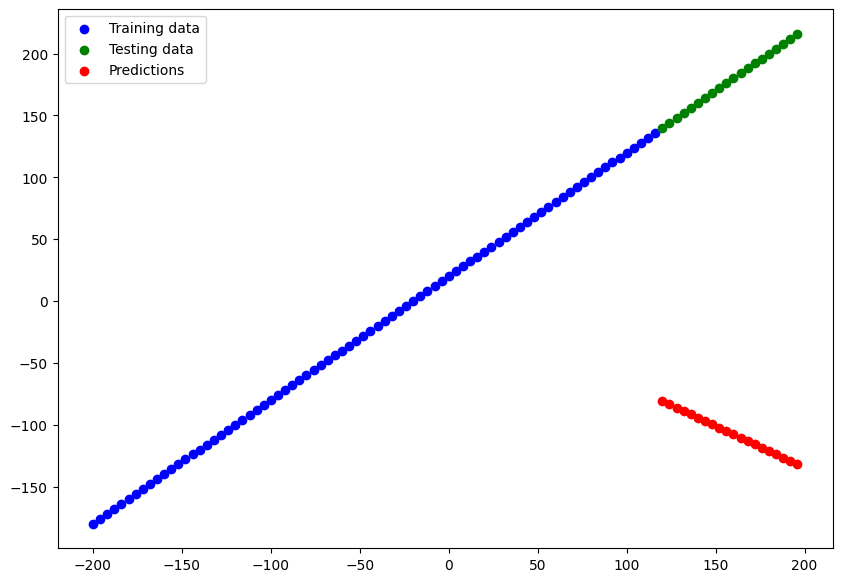

In [13]:
pred1 = model1.predict(x_test)

pltpred(x_train, y_train,
        x_test, y_test,
        pred1
        )

#### **Model 2 - Improved Single Neuron Approach**

Same setup as Model 1 but with some modifications such as increasing epoch count and using normalized features for `.fit()`.

##### Create and compile model

In [ ]:
model2 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(1)
])

model2.compile(loss='mse',
              optimizer='adam',
              metrics=["mse"]
              )

##### Show model summary

In [15]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [ ]:
history2 = model2.fit(tf.expand_dims(x_train_scaled, axis=-1), y_train, 
                      epochs=200)

Epoch 1/100


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - loss: 9247.7051 - mse: 9247.7051
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9247.0273 - mse: 9247.0273
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9246.3457 - mse: 9246.3457
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9245.6611 - mse: 9245.6611
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9245.0225 - mse: 9245.0225
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9244.3516 - mse: 9244.3516
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9243.7012 - mse: 9243.7012
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9242.9854 - mse: 9242.9854
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9242.3652 - mse: 9242.3652
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 9241.7109 - mse: 9241.7109
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9241.0566 - mse: 9241.0566
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9240.3701 - mse

Evaluate the model.

In [17]:
model2.evaluate(x_test_scaled, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - loss: 33051.9609 - mse: 33051.9609


[33051.9609375, 33051.9609375]

##### Showcase results.

In [18]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (36.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6 (28.00 B)

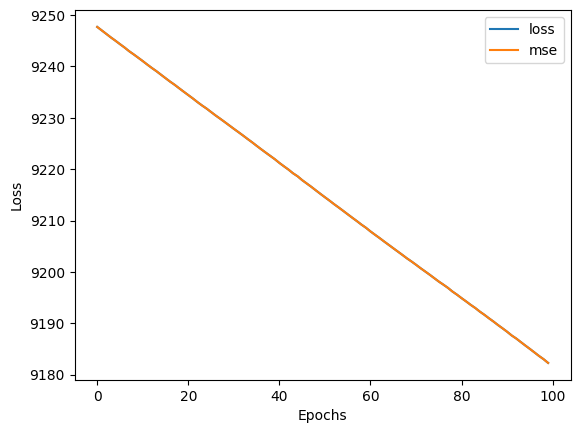

In [19]:
pd.DataFrame(history2.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


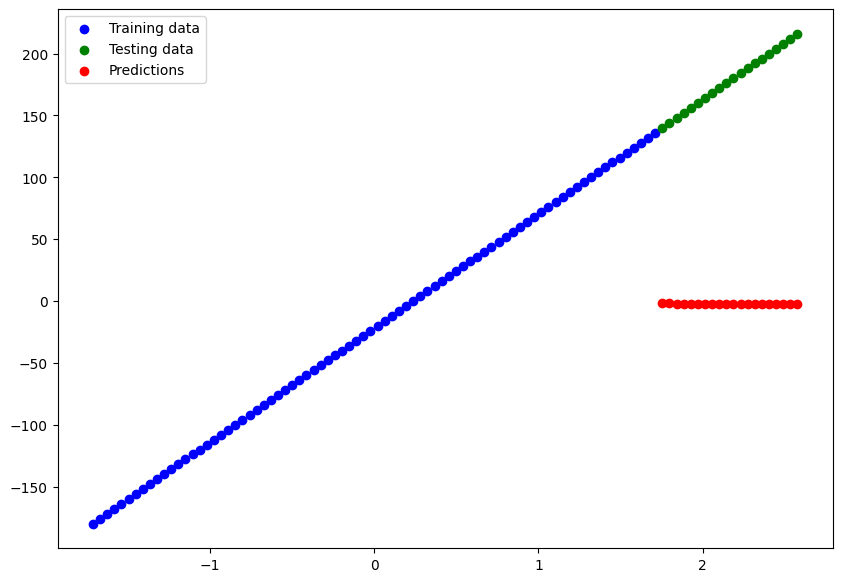

In [20]:
pred2 = model2.predict(x_test_scaled)

pltpred(x_train_scaled, y_train,
        x_test_scaled, y_test,
        pred2
        )

#### **Model 3 - Three Layer Approach**

A model with three layers each varying in neuron count.

##### Create and compile model

In [21]:
model3 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(8, activation='relu'),
  tf.keras.layers.Dense(4, activation='relu'),
  tf.keras.layers.Dense(1, activation='linear')
])

model3.compile(loss='mse',
              optimizer='adam',
              metrics=["mse"]
              )

##### Show model summary

In [22]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57 (228.00 B)

 Trainable params: 57 (228.00 B)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [ ]:
history3 = model3.fit(tf.expand_dims(x_train_scaled, axis=-1), y_train, 
                      epochs=200)

Epoch 1/100


I0000 00:00:1778685046.347668    6693 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5824__.9


1/3 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - loss: 8604.3320 - mse: 8604.3320

I0000 00:00:1778685048.350448    6695 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5824__.9


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 450ms/step - loss: 9008.7422 - mse: 9008.7422
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 9007.4717 - mse: 9007.4717
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9006.3311 - mse: 9006.3311
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9005.0469 - mse: 9005.0469
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9003.7148 - mse: 9003.7148
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 9002.4443 - mse: 9002.4443
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9001.1621 - mse: 9001.1621
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8999.7139 - mse: 8999.7139
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8998.2012 - mse: 8998.2012
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8996.8359 - mse: 8996.8359
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8995.3613 - mse: 8995.3613
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8993.7930 - mse

Evaluate the model.

In [24]:
model3.evaluate(x_test_scaled, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 884ms/step - loss: 31576.5508 - mse: 31576.5508


[31576.55078125, 31576.55078125]

##### Showcase results.

In [25]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173 (696.00 B)

 Trainable params: 57 (228.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 116 (468.00 B)

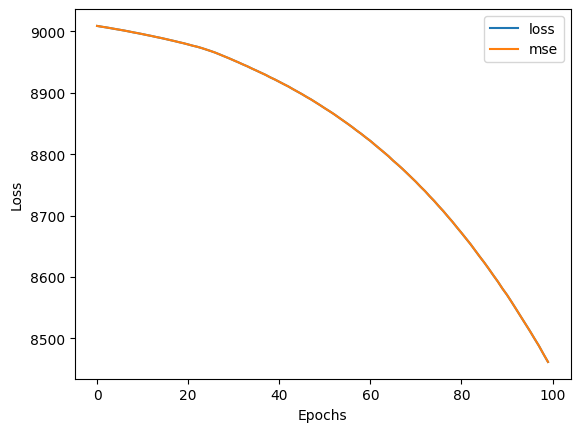

In [26]:
pd.DataFrame(history3.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step


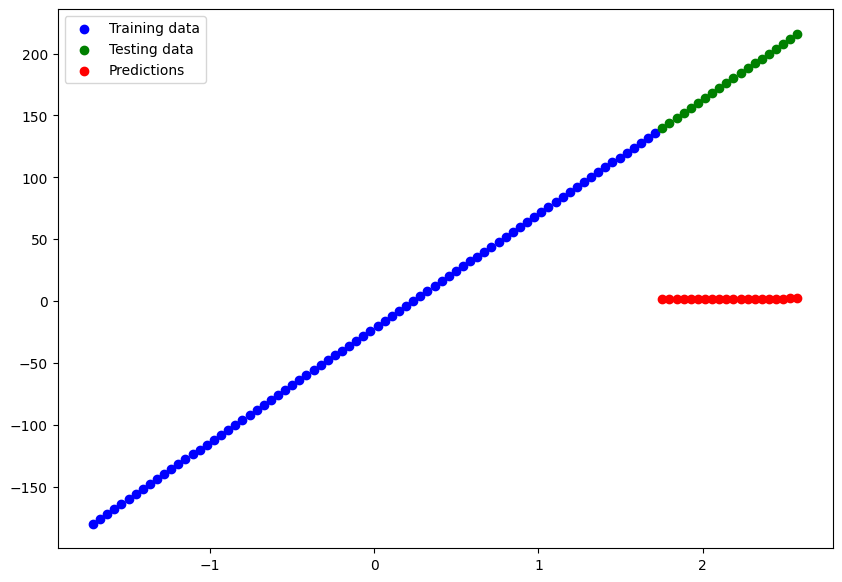

In [27]:
pred3 = model3.predict(x_test_scaled)

pltpred(x_train_scaled, y_train,
        x_test_scaled, y_test,
        pred3
        )